# Does the micelle bias follow the working point, or the number of crossings?

Across six nuclides the efficiency bias from omitting `micCorr` falls as the
efficiency rises. Restricted to the four dispersion-dominated nuclides it is
perfectly monotonic in efficiency — and **equally perfectly monotonic in the
number of droplet crossings**, because those two are themselves collinear:

| | ³H | ⁶³Ni | ¹⁴C | ⁹⁹Tc |
|---|---|---|---|---|
| bias / % | 0.62 | 0.35 | 0.12 | 0.03 |
| efficiency | 0.700 | 0.862 | 0.964 | 0.975 |
| crossings | ~14 | ~138 | ~1091 | ~4033 |

Two explanations fit that ordering exactly, and a cross-nuclide comparison
cannot separate them:

* **Working point.** The same photon-budget error displaces a steep efficiency
  curve more than a saturated one. This makes the bias a property of the
  *measurement*.
* **Crossing number.** The relative dispersion of the aqueous path length falls
  roughly as $1/\sqrt{N_{\text{cross}}}$, so a track that crosses thousands of
  droplets has a nearly deterministic path and little dispersion left to bias
  anything. This makes the bias a property of the *radionuclide*.

**This notebook separates them.** One radionuclide — ³H — is fitted at several
different measured TDCR ratios. The spectrum is identical at every point, so
the range, the droplet crossings and the retention distribution are identical
too. **Only the working point moves.**

* If the bias tracks the efficiency here, the working-point mechanism is real
  and the crossing-number explanation cannot account for it.
* If the bias is flat, the working point does nothing and the cross-nuclide
  ordering was the crossing number all along.

Either outcome settles the question. The prediction of the crossing-number
explanation alone is a flat line; the prediction of the working-point
explanation is the same fall seen across nuclides.


In [1]:
import importlib, io, contextlib, time, warnings
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from importlib.metadata import version

import tdcrpy.TDCR_model_lib as tl
import tdcrpy.TDCRPy as tm

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})
print(f'TDCRPy {version("TDCRPy")}')

TDCRPy 2.20.15


In [2]:
# ---- conditions: identical to micelleCheck, so the results are comparable --
RAD      = 'H-3'
KB       = 1e-5
V        = 10
N        = 500000
FAQ      = 0.10
DIAM     = 4
SIGMA    = 0.0
COCKTAIL = 'Ultima Gold'

# Measured ratios to fit. 0.668 is the value used in micelleCheck; the others
# are the same counter run better or worse. They span the efficiency curve
# from well below the usual working point to near saturation.
TD_SCAN = [0.40, 0.50, 0.60, 0.668, 0.75, 0.82, 0.88]

# Wide enough to reach the top of the scan. H-3's modelled TDCR rises
# monotonically to L = 60 (it does not turn over as Fe-55 and Cr-51 do), so a
# wide grid is safe for this nuclide.
L_GRID = np.logspace(np.log10(0.5), np.log10(60.0), 45)

NOMINAL = dict(fAq=tl.fAq, micCorr=tl.micCorr,
               diam=tl.diam_micelle, sigma=tl.sigma_micelle)


def set_state(micCorr):
    global tl, tm
    with contextlib.redirect_stdout(io.StringIO()):
        tl.modifyLScocktail(COCKTAIL, FAQ, 'Water', 0.0)
    tl.modifyDiam_micelle(DIAM)
    tl.modifySigma_micelle(SIGMA)
    tl.modifyMicCorr(bool(micCorr))
    tl = importlib.reload(tl)
    tm = importlib.reload(tm)


set_state(False)
print(f'{RAD} in {COCKTAIL} + {FAQ:.0%} water, {DIAM} nm droplets, '
      f'sigma = {SIGMA:g}')
print(f'kB = {KB} cm/keV, V = {V} mL, N = {N}')
print(f'fitting {len(TD_SCAN)} measured ratios: {TD_SCAN}')

H-3 in Ultima Gold + 10% water, 4 nm droplets, sigma = 0
kB = 1e-05 cm/keV, V = 10 mL, N = 500000
fitting 7 measured ratios: [0.4, 0.5, 0.6, 0.668, 0.75, 0.82, 0.88]


## 1. One simulation per arm, many working points

The decay histories do not depend on the ratio being fitted — only on the
nuclide and on whether the correction is active. So each arm is simulated
**once** and then replayed across a grid of `L`; every working point in the
scan is read off that one curve.

That is what makes this test cheap: seven fits for the price of two
simulations. It is also what makes it clean, because every point in the scan
uses the *same* decays.


In [3]:
scan = {}
for mic in (False, True):
    t0 = time.time()
    set_state(mic)
    tm.TDCRPy(2.0, RAD, '1', N, KB, V, record=True)     # one simulation
    tdcr, effd = [], []
    for Lg in L_GRID:
        o = tm.TDCRPy(Lg, RAD, '1', N, KB, V, readRecHist=True)
        tdcr.append(o[4] / o[2] if o[2] > 0 else np.nan)
        effd.append(o[2])
    tdcr, effd = np.array(tdcr), np.array(effd)
    order = np.argsort(tdcr)

    pts = {}
    for td_target in TD_SCAN:
        if not (np.nanmin(tdcr) < td_target < np.nanmax(tdcr)):
            print(f'  TD = {td_target}: outside the reachable range -- skipped')
            continue
        L_fit = float(np.interp(td_target, tdcr[order], L_GRID[order]))
        # one exact replay at the fitted L, rather than interpolating eff_D
        o = tm.TDCRPy(L_fit, RAD, '1', N, KB, V, readRecHist=True)
        pts[td_target] = dict(L=L_fit, D=o[2], uD=o[3],
                              tdcr=o[4] / o[2] if o[2] > 0 else np.nan)
    scan[mic] = dict(tdcr=tdcr, effd=effd, pts=pts)
    print(f'micCorr={str(mic):5s}: {len(pts)} working points   '
          f'[{time.time()-t0:.0f} s]', flush=True)

micCorr=False: 7 working points   [2915 s]


micCorr=True : 7 working points   [2787 s]


In [4]:
TD_OK = [t for t in TD_SCAN if t in scan[False]['pts'] and t in scan[True]['pts']]

rows = []
print(f'{"TD":>6s} {"L uncorr":>9s} {"L corr":>8s} | {"eff_D uncorr":>13s} '
      f'{"eff_D corr":>11s} {"bias %":>8s} {"+-":>6s} {"z":>6s}')
print('-' * 76)
for td_target in TD_OK:
    a, b = scan[False]['pts'][td_target], scan[True]['pts'][td_target]
    bias = 100 * (a['D'] - b['D']) / b['D']
    ubias = 100 * np.hypot(a['uD'], b['uD']) / b['D']
    rows.append(dict(TD=td_target, L_off=a['L'], L_on=b['L'],
                     D_off=a['D'], D_on=b['D'], bias=bias, ubias=ubias,
                     z=bias / ubias if ubias > 0 else np.nan))
    print(f'{td_target:6.3f} {a["L"]:9.4f} {b["L"]:8.4f} | {a["D"]:13.5f} '
          f'{b["D"]:11.5f} {bias:8.3f} {ubias:6.3f} {rows[-1]["z"]:6.2f}')

eff = np.array([r['D_on'] for r in rows])
bias = np.array([r['bias'] for r in rows])
ubias = np.array([r['ubias'] for r in rows])

    TD  L uncorr   L corr |  eff_D uncorr  eff_D corr   bias %     +-      z
----------------------------------------------------------------------------
 0.400    2.4454   2.7091 |       0.43936     0.43750    0.425  0.147   2.89
 0.500    3.4170   3.7817 |       0.54435     0.54159    0.510  0.128   3.99
 0.600    4.7796   5.2803 |       0.63947     0.63546    0.630  0.111   5.70
 0.668    6.1128   6.7400 |       0.69988     0.69476    0.738  0.099   7.42
 0.750    8.6658   9.4844 |       0.77122     0.76359    0.999  0.086  11.67
 0.820   12.7032  13.7798 |       0.83172     0.82145    1.251  0.073  17.12
 0.880   20.1596  21.4038 |       0.88489     0.87044    1.660  0.061  27.16


## 2. The test

The crossing number is identical at every point above — same nuclide, same
spectrum, same transport. So any dependence of the bias on the efficiency here
is the working point and nothing else.


In [5]:
CROSS = {'H-3': (0.700, 0.625), 'Cr-51': (0.739, 0.461), 'Fe-55': (0.800, 0.295),
         'Ni-63': (0.862, 0.348), 'C-14': (0.964, 0.124), 'Tc-99': (0.975, 0.030)}

rho, p_rho = spearmanr(eff, bias)

# The points share one pair of simulations -- the same recorded histories are
# replayed at every L -- so they are strongly correlated. A common fluctuation
# shifts the whole scan up or down and cannot create a trend, which is what
# makes the SHAPE well determined. But it also means the per-point error bars
# are largely common-mode, so a chi2 that assumes independence would be
# meaningless. The slope below is therefore quoted without one.
slope, intercept = np.polyfit(eff, bias, 1)
span_obs = bias.max() - bias.min()

# What the working-point explanation predicts over this same efficiency range,
# calibrated on the cross-nuclide data it was invented to explain.
ce = np.array([v[0] for v in CROSS.values()])
cb = np.array([v[1] for v in CROSS.values()])
o = np.argsort(ce)
pred_lo = float(np.interp(eff.min(), ce[o], cb[o]))
pred_hi = float(np.interp(eff.max(), ce[o], cb[o]))
span_pred = abs(pred_lo - pred_hi)

print(f'working points fitted : {len(eff)}')
print(f'efficiency range      : {eff.min():.3f} to {eff.max():.3f}')
print(f'bias range            : {bias.min():.3f} % to {bias.max():.3f} %')
print(f'typical uncertainty   : +-{np.mean(ubias):.3f} % per point '
      f'(largely common-mode)')
print(f'\nSpearman rho(bias, efficiency) = {rho:+.3f}   (ordering only;')
print('  its p-value assumes independent points and does not apply here)')
print(f'least-squares slope   : {slope:+.3f} % per unit efficiency')

print(f'\nObserved change in bias across the scan : {span_obs:.3f} %')
print(f'Working-point prediction over the same   : {span_pred:.3f} %')
print(f'  (cross-nuclide bias is {pred_lo:.3f} % at eff = {eff.min():.3f} '
      f'and {pred_hi:.3f} % at eff = {eff.max():.3f})')
ratio = span_obs / span_pred if span_pred > 0 else np.nan
print(f'  observed / predicted = {ratio:.2f}')

i_lo, i_hi = int(np.argmin(eff)), int(np.argmax(eff))
u_span = float(np.hypot(ubias[i_lo], ubias[i_hi]))   # conservative: correlated
falls = bias[i_hi] < bias[i_lo]
resolved = span_obs > 2 * u_span

print(f'\nchange across the scan : {span_obs:.3f} % +- {u_span:.3f} % '
      f'(conservative)')
print(f'  resolved at 2 sigma  : {"yes" if resolved else "no"}')
print(f'  direction            : bias {"falls" if falls else "rises"} '
      f'with efficiency')

print('\n' + '=' * 72)
if not resolved:
    print('WORKING POINT NOT SUPPORTED. Across an efficiency range where the')
    print(f'cross-nuclide data would require a change of {span_pred:.2f} %, the')
    print(f'bias changes by {span_obs:.3f} +- {u_span:.3f} % at fixed crossing')
    print('number -- consistent with no dependence at all. The cross-nuclide')
    print('ordering is therefore not a working-point effect, and the crossing')
    print("number is the surviving explanation. Section 3.4's claim retires.")
elif falls:
    if ratio > 0.5:
        print('WORKING POINT CONFIRMED. The bias falls with rising efficiency')
        print('at fixed crossing number, by an amount comparable to the')
        print('cross-nuclide fall. The working point is a genuine mechanism and')
        print('the cross-nuclide ordering need not be the crossing number.')
    else:
        print('WORKING POINT REAL BUT INSUFFICIENT. The bias does fall with')
        print('efficiency at fixed crossing number, but by much less than the')
        print('cross-nuclide ordering requires. Both mechanisms are present,')
        print('and the crossing number carries most of that ordering.')
else:
    print('UNEXPECTED. The bias RISES with efficiency at fixed crossing')
    print('number. Neither candidate explanation predicts this, and the')
    print('cross-nuclide ordering cannot be a working-point effect as stated.')
print('=' * 72)
print('\nNote: the scan points share one pair of simulations, so a common')
print('fluctuation moves all of them together and cannot fake a trend. The')
print('error bars shown are per-point and therefore conservative for the')
print('shape, which is what is being tested here.')

working points fitted : 7
efficiency range      : 0.438 to 0.870
bias range            : 0.425 % to 1.660 %
typical uncertainty   : +-0.101 % per point (largely common-mode)

Spearman rho(bias, efficiency) = +1.000   (ordering only;
  its p-value assumes independent points and does not apply here)
least-squares slope   : +2.659 % per unit efficiency

Observed change in bias across the scan : 1.234 %
Working-point prediction over the same   : 0.296 %
  (cross-nuclide bias is 0.625 % at eff = 0.438 and 0.329 % at eff = 0.870)
  observed / predicted = 4.18

change across the scan : 1.234 % +- 0.159 % (conservative)
  resolved at 2 sigma  : yes
  direction            : bias rises with efficiency

UNEXPECTED. The bias RISES with efficiency at fixed crossing
number. Neither candidate explanation predicts this, and the
cross-nuclide ordering cannot be a working-point effect as stated.

Note: the scan points share one pair of simulations, so a common
fluctuation moves all of them together and 

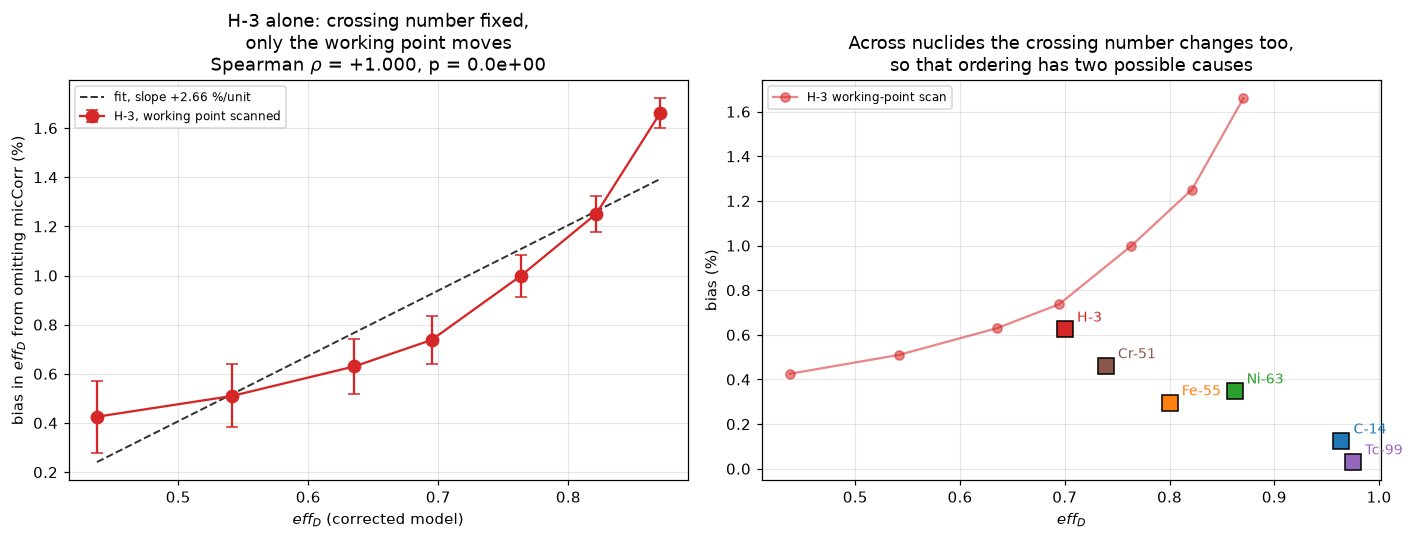

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.errorbar(eff, bias, yerr=ubias, fmt='o-', ms=8, capsize=4, color='#d62728',
            label=f'{RAD}, working point scanned')
xs = np.linspace(eff.min(), eff.max(), 50)
ax.plot(xs, slope * xs + intercept, '--', color='#333333', lw=1.3,
        label=f'fit, slope {slope:+.2f} %/unit')
ax.set_xlabel('$eff_D$ (corrected model)')
ax.set_ylabel('bias in $eff_D$ from omitting micCorr (%)')
ax.set_title(f'{RAD} alone: crossing number fixed,\nonly the working point '
             f'moves\n' + r'Spearman $\rho$ = ' + f'{rho:+.3f}, p = {p_rho:.1e}')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# the cross-nuclide picture, for contrast
ax = axes[1]
COL = {'H-3': '#d62728', 'Fe-55': '#ff7f0e', 'Cr-51': '#8c564b',
       'Ni-63': '#2ca02c', 'C-14': '#1f77b4', 'Tc-99': '#9467bd'}
for rad, (e, b) in CROSS.items():
    ax.plot(e, b, 's', ms=11, color=COL[rad], markeredgecolor='k')
    ax.annotate(rad, (e, b), textcoords='offset points', xytext=(8, 5),
                fontsize=9, color=COL[rad])
ax.plot(eff, bias, 'o-', ms=6, color='#d62728', alpha=0.55,
        label=f'{RAD} working-point scan')
ax.set_xlabel('$eff_D$'); ax.set_ylabel('bias (%)')
ax.set_title('Across nuclides the crossing number changes too,\n'
             'so that ordering has two possible causes')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('micelle_workingpoint.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
with contextlib.redirect_stdout(io.StringIO()):
    tl.modifyLScocktail(COCKTAIL, NOMINAL['fAq'], 'Water', 0.0)
tl.modifyDiam_micelle(NOMINAL['diam'])
tl.modifySigma_micelle(NOMINAL['sigma'])
tl.modifyMicCorr(NOMINAL['micCorr'])
tl = importlib.reload(tl); tm = importlib.reload(tm)
tl.cleanup_record_files()
print(f'restored: fAq={tl.fAq}, micCorr={tl.micCorr}, '
      f'diam={tl.diam_micelle}, sigma={tl.sigma_micelle}')

restored: fAq=0.0, micCorr=False, diam=4.0, sigma=0.0
